In [33]:
# https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

import numpy as np

In [34]:
df = pd.read_csv("../data/dataset.csv")

In [35]:
def simulate_user_preference(row):
    """
    Simulate a user who likes upbeat, danceable and happy music.
    Returns 1 (like) or 0 (dislike).
    """
    score = 0

    if row["danceability"] > 0.6:
        score += 1

    if row["energy"] > 0.5:
        score += 1

    if row["valence"] > 0.5:
        score += 1

    if row["acousticness"] < 0.4:
        score += 1

    label = 1 if score >= 3 else 0
    if np.random.random() < 0.15:
        label = 1 - label

    return label

df["label"] = df.apply(simulate_user_preference, axis = 1)

print(df["label"].value_counts())
print(f"\nLike Ratio: {df['label'].mean():.2%}")

label
0    59820
1    54180
Name: count, dtype: int64

Like Ratio: 47.53%


In [36]:
audio_features = [
    "danceability", "energy", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence", "tempo", "loudness"
]

X = df[audio_features]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

Accuracy: 82.43%


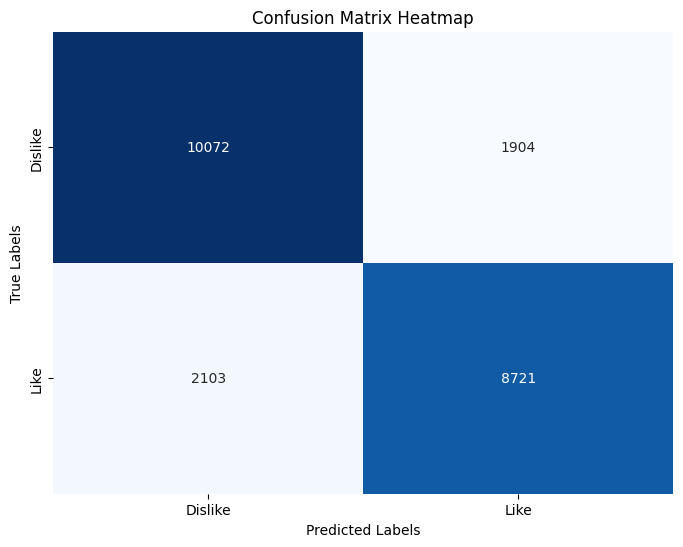

In [39]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', cbar=False, 
           xticklabels=['Dislike', 'Like'], yticklabels=['Dislike', 'Like'])

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

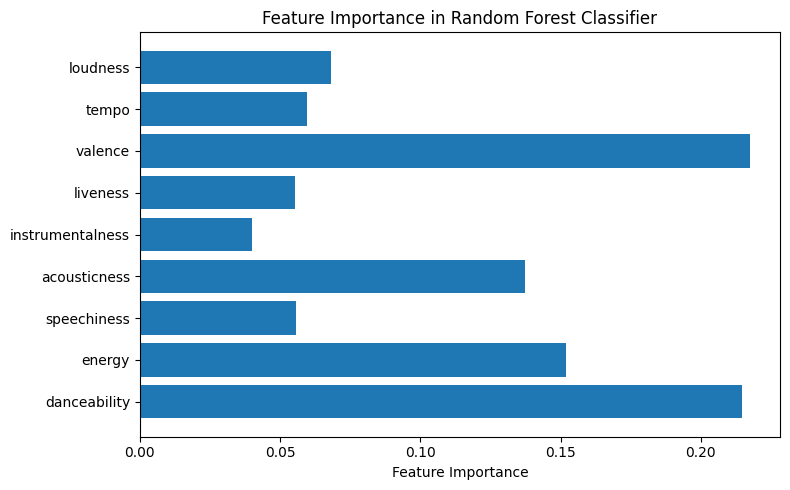

In [40]:
feature_importances = classifier.feature_importances_

plt.figure(figsize=(8, 5))
plt.barh(audio_features, feature_importances)
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.tight_layout()
plt.show()

In [55]:
import joblib
import os

MODEL_DIR = "../backend/models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(model, os.path.join(MODEL_DIR, "groove_model.pkl"))

['../backend/models/groove_model.pkl']